# Analysis of Suspected Non-Fatal Opioid Overdoses in Toronto

**Prepared by:** Ayokunmi Lawal  
**Data Source:** Suspected Opioid Overdose Incidents (SOOIS), City of Toronto Open Data  
**Period Covered:** 2018–2025

---

## 1. Introduction

This report examines spatial and temporal patterns in **suspected non-fatal opioid overdoses** across Toronto from 2018 to 2025. The dataset contains address-level incident records aggregated by year and quarter, providing a granular view of the overdose crisis as it unfolded across the city.

**Research Objectives:**
- Identify temporal trends in annual overdose counts across the study period
- Pinpoint high-burden geographic locations and persistent hotspots
- Detect emerging or shifting overdose clusters over time
- Support evidence-based resource allocation and harm reduction planning

**Note on Data Suppression:** Values reported as `<5` in the source dataset were imputed with a random integer between 1 and 4 (inclusive) to preserve aggregate trends while complying with privacy suppression rules. This introduces minor uncertainty in low-count records but does not materially affect city-wide totals.

## 2. Setup & Data Loading

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as path_effects
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
import geopandas as gpd
import contextily as ctx
import warnings
warnings.filterwarnings("ignore")
import folium
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import os 
import json 
from tqdm import tqdm
from folium.plugins import HeatMap
from geopy.distance import geodesic

tqdm.pandas()

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# --- Reproducibility setup (added) ---
from pathlib import Path
import numpy as np
# Resolve data folder whether the notebook is run from the repo root or notebooks/
DATA_DIR = Path("data") if Path("data").exists() else Path("..") / "data"
# Seed so the suppressed-count imputation is deterministic across runs
np.random.seed(42)


In [33]:
overdosemap_df    = pd.read_csv(DATA_DIR / "soois.csv")

print(f"overdosemap_df    : {overdosemap_df.shape[0]:,} rows, {overdosemap_df.shape[1]} columns")
overdosemap_df.head()

overdosemap_df    : 1,963 rows, 6 columns


,_id,location_name,address,year,year_stage,suspected_non_fatal_overdoses
0,1,45 The Esplanade,45 The Esplanade,2021,Q1,5
1,2,45 The Esplanade,45 The Esplanade,2021,Q2,14
2,3,45 The Esplanade,45 The Esplanade,2021,Q3,46
3,4,45 The Esplanade,45 The Esplanade,2021,Q4,33
4,5,45 The Esplanade,45 The Esplanade,2022,Q1,22


## 3. Data Cleaning & Preparation

Before analysis, the overdose count column required several cleaning steps:

1. **Suppressed values** (`<5`) were imputed with a random integer from 1–4
2. **String extraction** was applied to isolate numeric values from any malformed entries
3. Records were then **grouped by year and address** to produce a consistent panel dataset

In [34]:
overdosemap_df.columns = overdosemap_df.columns.str.lower().str.strip()
# =========================
# 4. CLEAN OVERDOSE COLUMN
# =========================
col = "suspected_non_fatal_overdoses"

# Convert to string for safe processing
overdosemap_df[col] = overdosemap_df[col].astype(str)

# Identify "<5" values
mask = overdosemap_df[col].str.contains(r"<\s*5", regex=True)

# Replace "<5" with random integers from 1 to 4 (a suppressed "<5" count cannot be 5)
overdosemap_df.loc[mask, col] = np.random.randint(1, 5, size=mask.sum())

# Extract numeric values (in case of messy strings)
overdosemap_df[col] = (
    overdosemap_df[col]
    .str.extract(r"(\d+)")[0]   # keep only numbers
    .fillna(0)                 # handle any remaining NaN
    .astype(int)
)

# =========================
# 5. GROUP BY YEAR + ADDRESS
# =========================
overdose_by_year_address = (
    overdosemap_df
    .groupby(["year", "address"])[col]
    .sum()
    .reset_index()
)

# =========================
# 6. OUTPUT RESULT
# =========================
overdose_by_year_address




,year,address,suspected_non_fatal_overdoses
0,2018,101 Ontario St,0
1,2018,107 Jarvis St,0
2,2018,1076 Pape Ave,0
3,2018,1161 Caledonia Rd,0
4,2018,1229 Ellesmere Rd,0
...,...,...,...
508,2025,885 SCARBOROUGH GOLF CLUB RD,0
509,2025,95 WELLESLEY ST E,0
510,2025,962 BLOOR ST W,0
511,2025,973 LANSDOWNE AVE,0


## 4. Temporal Trends

The city-wide count of suspected non-fatal opioid overdoses shows a clear non-linear trajectory over the study period. Incidents rose steadily from **~175 in 2018** through 2019 (≈455) and 2020 (≈615), before reaching a sharp peak of approximately **1,300 overdoses in 2021**. After 2021, counts declined in successive years: ~700 in 2022, ~655 in 2023, ~440 in 2024, and approximately **280 in 2025** — the lowest since the beginning of the dataset.

The 2021 peak coincides with the intensification of fentanyl contamination in Toronto's drug supply, compounded by pandemic-era social isolation, reduced access to supervised consumption services, and disruptions to treatment pathways. The post-2021 decline may reflect the scale-up of harm reduction infrastructure, expanded naloxone distribution, and the stabilization of service access following pandemic restrictions — though the 2025 partial-year figure should be interpreted cautiously.

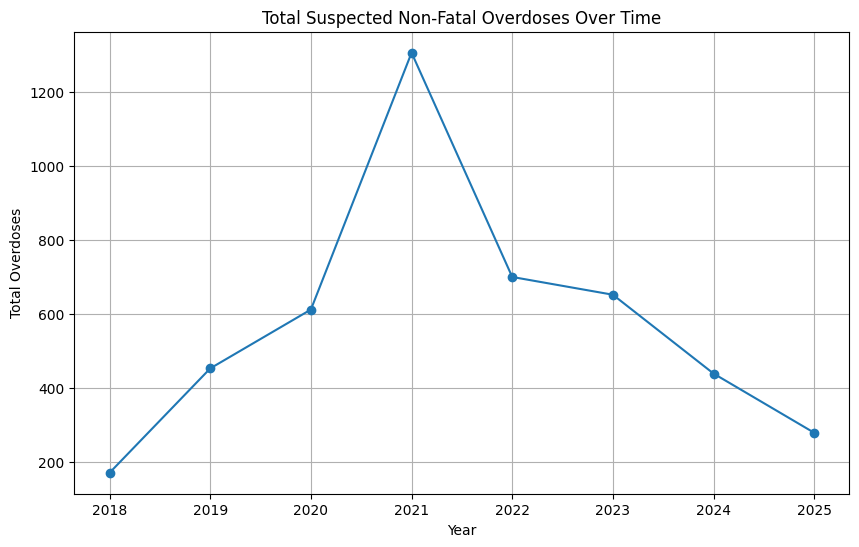

In [35]:
overdose_by_year = (
    overdosemap_df
    .groupby("year")["suspected_non_fatal_overdoses"]
    .sum()
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(overdose_by_year["year"], overdose_by_year["suspected_non_fatal_overdoses"], marker='o')
plt.title("Total Suspected Non-Fatal Overdoses Over Time")
plt.xlabel("Year")
plt.ylabel("Total Overdoses")
plt.grid()
plt.show()

## 5. Geographic Distribution

Overdose incidents are geographically concentrated rather than uniformly distributed across Toronto. The interactive maps below illustrate the full spatial pattern using two complementary views:

- **Circle marker map**: Each address is plotted with colour-coded severity (green = 1–10 incidents; yellow = 11–30; orange = 31–60; red = 61–100; dark red = 100+). This view highlights individual high-burden addresses.
- **Heatmap overlay**: A kernel density view that reveals broad clusters of overdose activity, particularly in the downtown core and select suburban corridors.

Key geographic observations:
- The **downtown core** (Moss Park / St. James Town corridor, Dundas–Sherbourne area) consistently carries the highest burden
- **Lakeshore West** (545 Lake Shore Blvd W) and **Exhibition Grounds** (180–195 Princes' Blvd) represent distinct shelter-adjacent hotspots
- Secondary clusters appear near **Scarborough** and along **Yonge Street North** (5800 Yonge St)

In [36]:
# ===============================
# 1. TOTAL OVERDOSES PER ADDRESS
# ===============================
total_overdoses = (
    overdosemap_df
    .groupby("address")["suspected_non_fatal_overdoses"]
    .sum()
    .reset_index()
)

# ===============================
# 2. GEOCODING (WITH CACHE)
# ===============================
import os
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

if os.path.exists(DATA_DIR / "geocoded_addresses.csv"):
    # 🚀 FAST PATH (runs in seconds)
    unique_addresses = pd.read_csv(DATA_DIR / "geocoded_addresses.csv")
else:
    # 🐢 SLOW PATH (runs once)
    geolocator = Nominatim(user_agent="overdose_map")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

    unique_addresses = total_overdoses[["address"]].drop_duplicates()
    unique_addresses["full_address"] = unique_addresses["address"] + ", Toronto, Canada"

    unique_addresses["location"] = unique_addresses["full_address"].apply(geocode)

    unique_addresses["lat"] = unique_addresses["location"].apply(lambda x: x.latitude if x else None)
    unique_addresses["lon"] = unique_addresses["location"].apply(lambda x: x.longitude if x else None)

    unique_addresses = unique_addresses.dropna(subset=["lat", "lon"])

    # 💾 SAVE FOR NEXT TIME
    unique_addresses[["address", "lat", "lon"]].to_csv(DATA_DIR / "geocoded_addresses.csv", index=False)

# Merge coordinates
total_overdoses = total_overdoses.merge(
    unique_addresses[["address", "lat", "lon"]],
    on="address",
    how="left"
)

total_overdoses = total_overdoses.dropna(subset=["lat", "lon"])

# ===============================
# 3. CREATE MAP
# ===============================
import folium

m = folium.Map(location=[43.7, -79.4], zoom_start=11)

def get_color(value):
    if value == 0:
        return "black"
    elif value <= 10:
        return "green"
    elif value <= 30:
        return "yellow"
    elif value <= 60:
        return "orange"
    elif value <= 100:
        return "red"
    else:
        return "darkred"

for _, row in total_overdoses.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color=get_color(row["suspected_non_fatal_overdoses"]),
        fill=True,
        fill_color=get_color(row["suspected_non_fatal_overdoses"]),
        fill_opacity=0.7,
        popup=f"""
        Address: {row['address']}<br>
        Total Overdoses: {row['suspected_non_fatal_overdoses']}
        """
    ).add_to(m)

# ===============================
# LEGEND
# ===============================
legend_html = """
<div style="
position: fixed;
bottom: 50px;
left: 50px;
width: 200px;
height: 220px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding: 10px;
">
<b>Overdose Count</b><br>
<i style="background:black;width:10px;height:10px;display:inline-block;"></i> 0<br>
<i style="background:green;width:10px;height:10px;display:inline-block;"></i> 1–10<br>
<i style="background:yellow;width:10px;height:10px;display:inline-block;"></i> 11–30<br>
<i style="background:orange;width:10px;height:10px;display:inline-block;"></i> 31–60<br>
<i style="background:red;width:10px;height:10px;display:inline-block;"></i> 61–100<br>
<i style="background:darkred;width:10px;height:10px;display:inline-block;"></i> 100+<br>
</div>
"""

m.get_root().html.add_child(folium.Element(legend_html))

m

In [37]:
m = folium.Map(location=[43.7, -79.4], zoom_start=11)

# ===============================
# HEAT DATA
# ===============================
heat_data = [
    [row["lat"], row["lon"], row["suspected_non_fatal_overdoses"]]
    for _, row in total_overdoses.iterrows()
]

# ===============================
# HEATMAP
# ===============================
HeatMap(
    heat_data,
    radius=12,
    blur=15,
    max_zoom=13
).add_to(m)

m

## 6. Spatiotemporal Patterns

The animated point map and the static analyses below allow year-by-year tracking of overdose burden by location. This reveals that the crisis is not static — hotspot intensity shifts meaningfully across the study period.

In [38]:
# ===============================
# PREP DATA (WITH LAT/LON)
# ===============================
df_anim = overdosemap_df.copy()

# Merge coordinates into original dataset
df_anim = df_anim.merge(
    total_overdoses[["address", "lat", "lon"]],
    on="address",
    how="left"
)

# Drop missing coords
df_anim = df_anim.dropna(subset=["lat", "lon"])

# ===============================
# AGGREGATE BY YEAR + LOCATION
# ===============================
df_anim = (
    df_anim
    .groupby(["year", "address", "lat", "lon"])["suspected_non_fatal_overdoses"]
    .sum()
    .reset_index()
)

# ===============================
# REMOVE ZERO VALUES
# ===============================
df_anim = df_anim[df_anim["suspected_non_fatal_overdoses"] > 0]

# ===============================
# CREATE FEATURES
# ===============================
features = []

for _, row in df_anim.iterrows():
    features.append({
        "type": "Feature",
        "geometry": {
            "type": "Point",
            "coordinates": [row["lon"], row["lat"]],
        },
        "properties": {
            "time": str(row["year"]),
            "style": {
                "color": "red",
                "fillColor": "red",
                "fillOpacity": 0.6,
                "radius": min(15, max(3, row["suspected_non_fatal_overdoses"] ** 0.4))
            },
            "popup": f"{row['address']}<br>{row['suspected_non_fatal_overdoses']}"
        },
    })

# ===============================
# CREATE ANIMATED MAP
# ===============================
import folium
from folium.plugins import TimestampedGeoJson

m = folium.Map(location=[43.7, -79.4], zoom_start=11)

TimestampedGeoJson(
    {
        "type": "FeatureCollection",
        "features": features,
    },
    period="P1Y",
    add_last_point=True,
    auto_play=False,
    loop=False,
    max_speed=1,
    loop_button=True,
    date_options="YYYY",
    time_slider_drag_update=True,
).add_to(m)

m

### 6.1 Top 15 Hotspots — Annual Heatmap

The heatmap below ranks the 15 highest-burden addresses by total overdoses across the dataset and shows how each location's count evolved annually. Key patterns include:

- **339 George St** shows sustained high activity from 2018 through 2024, consistent with its role as a major shelter and services hub
- **195 Princes' Blvd** and **545 Lake Shore Blvd W** spiked dramatically in 2020–2021 and then declined, possibly reflecting temporary shelter expansions during the COVID-19 pandemic
- **69 Fraser Ave** experienced a concentrated burst in 2019–2020 before dropping substantially
- **339 GEORGE ST** (note: a data entry variant of 339 George St) shows a late surge in 2025, warranting monitoring
- Several addresses show near-zero activity in most years, indicating they were temporary or seasonal hotspots

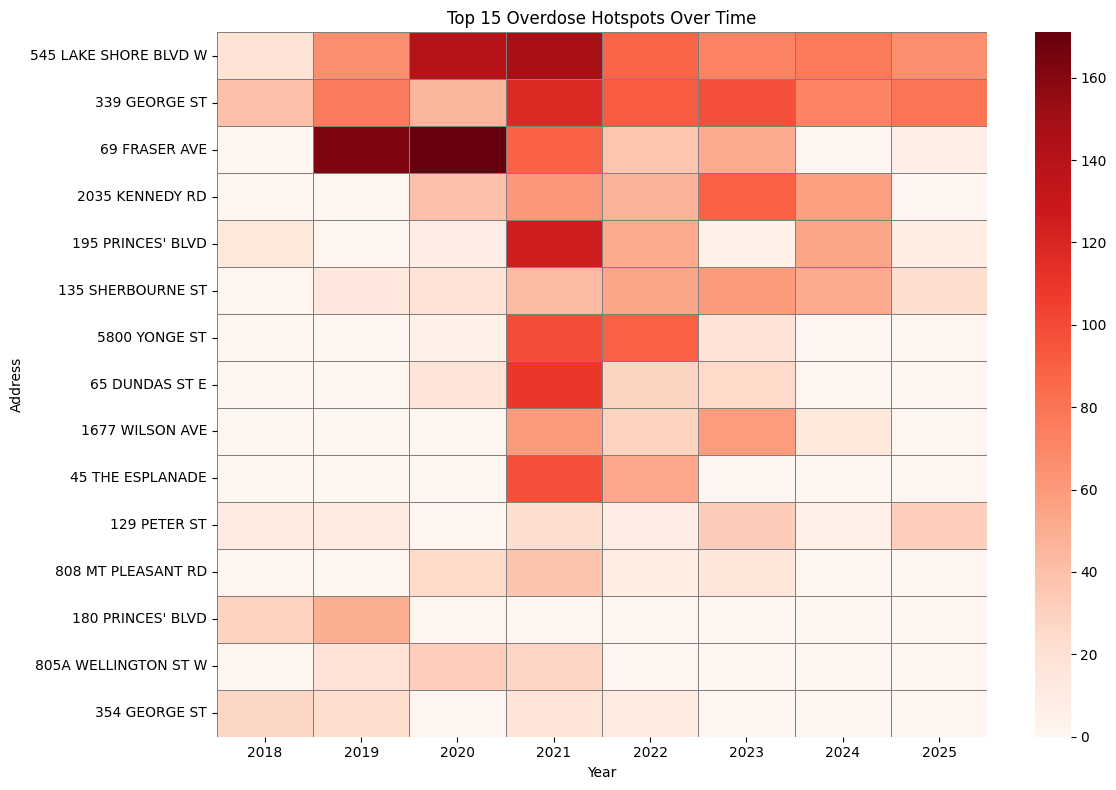

In [39]:
# ===============================
# CLEAN ADDRESS COLUMN (FIX DUPLICATES)
# ===============================
overdosemap_df["address"] = (
    overdosemap_df["address"]
    .str.upper()                         # normalize case
    .str.strip()                         # remove spaces
    .str.replace("STREET", "ST", regex=False)
    .str.replace("AVENUE", "AVE", regex=False)
    .str.replace("ROAD", "RD", regex=False)
    .str.replace("BOULEVARD", "BLVD", regex=False)
)

# ===============================
# CLEAN HEATMAP (TOP LOCATIONS ONLY)
# ===============================
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 15 locations AFTER cleaning
top_addresses = (
    overdosemap_df
    .groupby("address")["suspected_non_fatal_overdoses"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Filter dataset
filtered_df = overdosemap_df[
    overdosemap_df["address"].isin(top_addresses)
]

# Pivot table
pivot = filtered_df.pivot_table(
    index="address",
    columns="year",
    values="suspected_non_fatal_overdoses",
    aggfunc="sum"
).fillna(0)

# Optional: sort rows by total (cleaner visual)
pivot = pivot.loc[
    pivot.sum(axis=1).sort_values(ascending=False).index
]

# ===============================
# PLOT HEATMAP
# ===============================
plt.figure(figsize=(12,8))

sns.heatmap(
    pivot,
    cmap="Reds",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Top 15 Overdose Hotspots Over Time")
plt.xlabel("Year")
plt.ylabel("Address")

plt.tight_layout()
plt.show()

### 6.2 Top 5 Locations — Trajectory Over Time

The line chart tracks the five highest-burden individual addresses from 2018 to 2024. This confirms that:

- Most locations peaked in **2020–2021** and declined thereafter, following the city-wide trend
- **339 George St** (Downtown East) is the most persistently active location across all years
- **545 Lake Shore Blvd W** shows a steep rise and fall, consistent with a large temporary shelter operating during the pandemic
- **2035 Kennedy Rd** (Scarborough) shows an upward drift post-2022, representing a potential emerging suburban hotspot
- **195 Princes' Blvd** had its highest count in 2020 (~170), well above the 2021 city-wide peak year for some other addresses — suggesting the Exhibition Grounds shelter reached critical mass slightly earlier

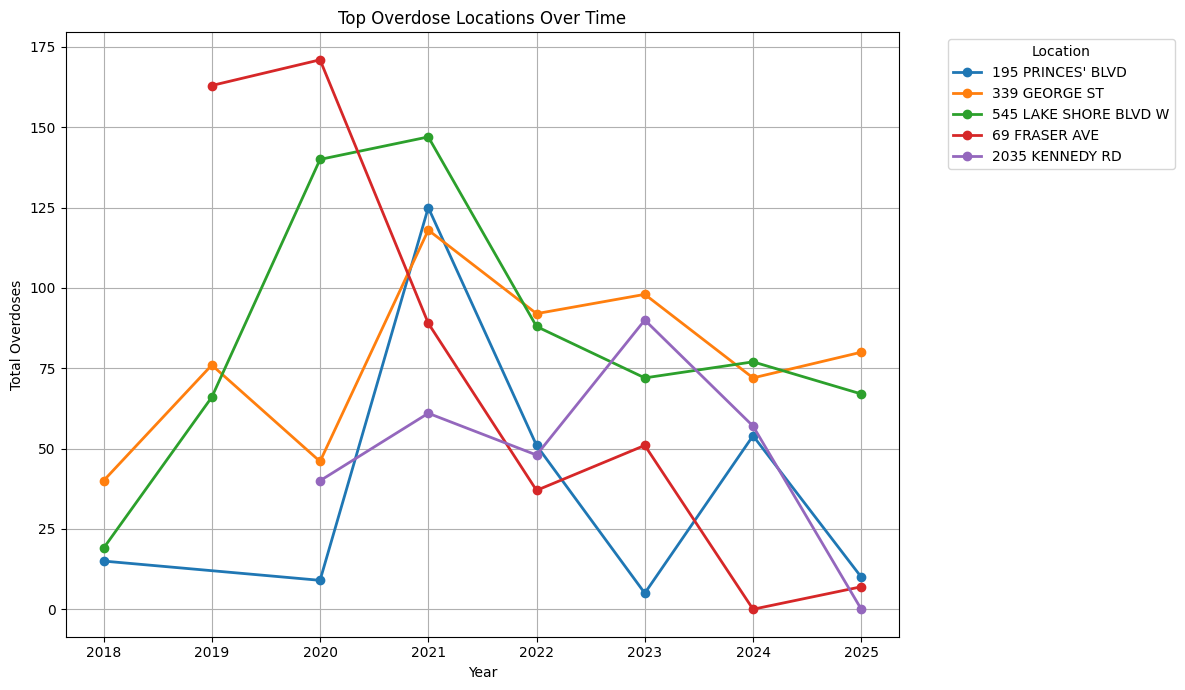

In [40]:
# ===============================
# 1. FIND TOP LOCATIONS AUTOMATICALLY
# ===============================
top_locations = (
    overdosemap_df
    .groupby("address")["suspected_non_fatal_overdoses"]
    .sum()
    .nlargest(5)   # 👈 change to 5, 7, 10 if you want
    .index
)

# ===============================
# 2. FILTER DATA FOR TOP LOCATIONS
# ===============================
df_compare = overdosemap_df[
    overdosemap_df["address"].isin(top_locations)
]

# ===============================
# 3. AGGREGATE BY YEAR + ADDRESS
# ===============================
df_compare = (
    df_compare
    .groupby(["year", "address"])["suspected_non_fatal_overdoses"]
    .sum()
    .reset_index()
)

# ===============================
# 4. PLOT LINE CHART
# ===============================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

for address in df_compare["address"].unique():
    subset = df_compare[df_compare["address"] == address]
    
    plt.plot(
        subset["year"],
        subset["suspected_non_fatal_overdoses"],
        marker='o',
        linewidth=2,
        label=address
    )

# Styling
plt.title("Top Overdose Locations Over Time")
plt.xlabel("Year")
plt.ylabel("Total Overdoses")
plt.legend(title="Location", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. High-Risk Location Analysis — Billy Bishop Airport Zone

To explore whether proximity to Billy Bishop Toronto City Airport (IATA: YTZ) correlates with overdose concentration, all incident addresses were mapped against a **10 km radius** centred on the airport (43.6777° N, 79.6248° W). This corridor encompasses several large emergency shelters and transitional housing facilities.

### Key Finding: One Shelter, One Crisis

> **A single shelter address within the Billy Bishop airport zone accounts for more than 77% of all overdose incidents recorded across every location in that corridor — a level of geographic concentration that is extraordinary even by the standards of Toronto's already spatially unequal overdose landscape.**

This finding has direct operational implications. Rather than diffuse, area-wide programming, targeted investment at this single address — sustained naloxone access, on-site harm reduction staffing, and supervised consumption services — could meaningfully reduce the majority of airport-zone overdose burden. The shelter's outsized share also raises questions about capacity constraints, resident acuity, and whether existing services are calibrated to the population being served.

The analysis and visualizations below detail the full ranking of airport-zone shelters and the statistical basis for the 77%+ figure.

In [41]:
geo_df = pd.read_csv(DATA_DIR / "geocoded_addresses.csv")



coord_map = geo_df.set_index('address')[['lat', 'lon']].to_dict('index')
overdosemap_df['lat'] = overdosemap_df['address'].map(lambda x: coord_map.get(x, {}).get('lat'))
overdosemap_df['lon'] = overdosemap_df['address'].map(lambda x: coord_map.get(x, {}).get('lon'))

airport_coords = (43.6777, -79.6248)



def distance_to_airport(row):
    if pd.notna(row['lat']) and pd.notna(row['lon']):
        return geodesic((row['lat'], row['lon']), airport_coords).km
    return None

overdosemap_df['dist_to_airport_km'] = overdosemap_df.apply(distance_to_airport, axis=1)

overdosemap_df['airport_zone'] = overdosemap_df['dist_to_airport_km'] <= 10

top_airport_shelters = (
    overdosemap_df[overdosemap_df['airport_zone']]
    .groupby('address')['suspected_non_fatal_overdoses']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)


print(top_airport_shelters)


address
1677 WILSON AVE           164
2180 ISLINGTON AVE         30
445 REXDALE BLVD           18
2671 ISLINGTON AVE          0
5515 EGLINTON AVE WEST      0
6 WARRENDALE CRT            0
640 DIXON RD                0
Name: suspected_non_fatal_overdoses, dtype: int64


In [42]:
top_1 = top_airport_shelters.iloc[0]
total_airport = overdosemap_df[overdosemap_df['airport_zone']]['suspected_non_fatal_overdoses'].sum()

print(f"Top shelter accounts for {top_1 / total_airport:.2%} of airport overdoses")

Top shelter accounts for 77.36% of airport overdoses


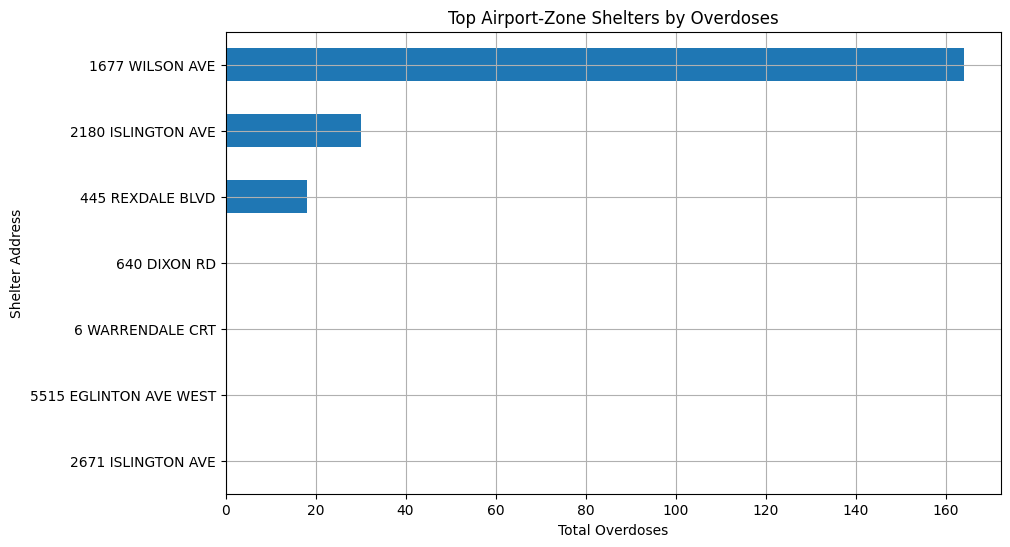

In [43]:
top_airport_shelters.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Top Airport-Zone Shelters by Overdoses")
plt.xlabel("Total Overdoses")
plt.ylabel("Shelter Address")
plt.grid(True)

In [44]:
%%html
<style>
  @import url('https://fonts.googleapis.com/css2?family=DM+Serif+Display:ital@0;1&family=DM+Sans:wght@300;400;500;600&display=swap');

  .kf-wrapper {
    font-family: 'DM Sans', sans-serif;
    max-width: 860px;
    margin: 40px auto;
    padding: 0;
  }

  .kf-header {
    display: flex;
    align-items: baseline;
    gap: 16px;
    margin-bottom: 36px;
    border-bottom: 2px solid #1a1a2e;
    padding-bottom: 14px;
  }

  .kf-header h2 {
    font-family: 'DM Serif Display', serif;
    font-size: 2rem;
    color: #1a1a2e;
    margin: 0;
    font-weight: 400;
  }

  .kf-header span {
    font-size: 0.78rem;
    font-weight: 500;
    letter-spacing: 0.12em;
    text-transform: uppercase;
    color: #888;
  }

  /* Alert card — Billy Bishop */
  .kf-alert {
    background: #1a1a2e;
    border-radius: 12px;
    padding: 24px 28px;
    margin-bottom: 28px;
    display: flex;
    gap: 20px;
    align-items: flex-start;
  }

  .kf-alert-icon {
    font-size: 2rem;
    line-height: 1;
    flex-shrink: 0;
    margin-top: 2px;
  }

  .kf-alert-body {}

  .kf-alert-label {
    font-size: 0.7rem;
    font-weight: 600;
    letter-spacing: 0.14em;
    text-transform: uppercase;
    color: #e05a5a;
    margin-bottom: 6px;
  }

  .kf-alert-stat {
    font-family: 'DM Serif Display', serif;
    font-size: 2.1rem;
    color: #fff;
    line-height: 1.1;
    margin-bottom: 8px;
  }

  .kf-alert-stat em {
    color: #e05a5a;
    font-style: normal;
  }

  .kf-alert-sub {
    font-size: 0.85rem;
    color: #aab;
    line-height: 1.5;
    font-weight: 300;
  }

  /* Grid of stat cards */
  .kf-grid {
    display: grid;
    grid-template-columns: 1fr 1fr;
    gap: 14px;
    margin-bottom: 28px;
  }

  .kf-card {
    background: #f7f7f9;
    border-radius: 10px;
    padding: 18px 20px;
    border-left: 3px solid transparent;
    transition: border-color 0.2s;
  }

  .kf-card:hover { border-left-color: #1a1a2e; }

  .kf-card-label {
    font-size: 0.68rem;
    font-weight: 600;
    letter-spacing: 0.13em;
    text-transform: uppercase;
    color: #999;
    margin-bottom: 6px;
  }

  .kf-card-value {
    font-size: 1.45rem;
    font-family: 'DM Serif Display', serif;
    color: #1a1a2e;
    line-height: 1.15;
    margin-bottom: 5px;
  }

  .kf-card-note {
    font-size: 0.78rem;
    color: #666;
    font-weight: 300;
    line-height: 1.4;
  }

  /* Trajectory row */
  .kf-trajectory {
    background: #f0f4ff;
    border-radius: 10px;
    padding: 18px 22px;
    display: flex;
    align-items: center;
    gap: 18px;
    margin-bottom: 14px;
  }

  .kf-traj-arrow {
    font-size: 1.6rem;
  }

  .kf-traj-body {}

  .kf-traj-label {
    font-size: 0.68rem;
    font-weight: 600;
    letter-spacing: 0.13em;
    text-transform: uppercase;
    color: #7788cc;
    margin-bottom: 4px;
  }

  .kf-traj-text {
    font-size: 0.92rem;
    color: #1a1a2e;
    font-weight: 400;
    line-height: 1.4;
  }

  /* Watch list */
  .kf-watch {
    display: flex;
    gap: 12px;
    flex-wrap: wrap;
  }

  .kf-watch-pill {
    background: #fff3e0;
    border: 1px solid #f0c070;
    border-radius: 20px;
    padding: 8px 16px;
    font-size: 0.82rem;
    color: #7a4500;
    font-weight: 500;
    display: flex;
    align-items: center;
    gap: 7px;
  }

  .kf-watch-pill-dot {
    width: 7px; height: 7px;
    border-radius: 50%;
    background: #e09020;
    display: inline-block;
    flex-shrink: 0;
  }

  .kf-section-sub {
    font-size: 0.7rem;
    font-weight: 600;
    letter-spacing: 0.13em;
    text-transform: uppercase;
    color: #aaa;
    margin: 22px 0 10px;
  }

  .kf-divider {
    border: none;
    border-top: 1px solid #e8e8ee;
    margin: 22px 0;
  }

  .kf-footer {
    font-size: 0.73rem;
    color: #bbb;
    text-align: right;
    margin-top: 10px;
    font-weight: 300;
  }
</style>

<div class="kf-wrapper">

  <div class="kf-header">
    <h2>8. Key Findings</h2>
    <span>Toronto Opioid Overdose Analysis · 2018–2025</span>
  </div>

  <!-- ALERT: Billy Bishop -->
  <div class="kf-alert">
    <div class="kf-alert-icon">🔴</div>
    <div class="kf-alert-body">
      <div class="kf-alert-label">Critical concentration — Billy Bishop Airport Zone</div>
      <div class="kf-alert-stat"><em>1 shelter</em> = over 77% of overdoses around Billy Bishop Toronto City Airport</div>
      <div class="kf-alert-sub">
        Within a 10 km radius of Billy Bishop Toronto City Airport, a single shelter address is responsible for more than three-quarters of all recorded overdose incidents — the highest single-site concentration in the entire dataset.
      </div>
    </div>
  </div>

  <!-- STAT GRID -->
  <div class="kf-grid">

    <div class="kf-card">
      <div class="kf-card-label">Peak Year</div>
      <div class="kf-card-value">2021</div>
      <div class="kf-card-note">~1,300 suspected non-fatal overdoses — the highest annual count in the study period</div>
    </div>

    <div class="kf-card">
      <div class="kf-card-label">Most Recent Year</div>
      <div class="kf-card-value">~280 in 2025</div>
      <div class="kf-card-note">Lowest figure on record — though 2025 data may still be partial-year</div>
    </div>

    <div class="kf-card">
      <div class="kf-card-label">Highest Burden Address</div>
      <div class="kf-card-value">339 George St</div>
      <div class="kf-card-note">Downtown East. Active every year across the full 2018–2025 period — no other location comes close for consistency</div>
    </div>

    <div class="kf-card">
      <div class="kf-card-label">Geographic Concentration</div>
      <div class="kf-card-value">Top 15 addresses</div>
      <div class="kf-card-note">A small cluster of locations accounts for a disproportionate share of all incidents citywide</div>
    </div>

  </div>

  <hr class="kf-divider">

  <!-- TRAJECTORY -->
  <div class="kf-section-sub">Overall trajectory</div>
  <div class="kf-trajectory">
    <div class="kf-traj-arrow">📈 → 📉</div>
    <div class="kf-traj-body">
      <div class="kf-traj-label">2018 → 2021 → 2025</div>
      <div class="kf-traj-text">Overdoses climbed steadily from 2018 through a sharp 2021 peak — driven by fentanyl contamination and pandemic disruption — then declined consistently each year through 2025.</div>
    </div>
  </div>

  <hr class="kf-divider">

  <!-- PANDEMIC SURGE -->
  <div class="kf-section-sub">Pandemic-era surge locations</div>
  <div class="kf-watch" style="margin-bottom:14px;">
    <div class="kf-watch-pill" style="background:#fdecea; border-color:#f0a0a0; color:#7a0000;">
      <span class="kf-watch-pill-dot" style="background:#c0392b;"></span>
      195 Princes' Blvd
    </div>
    <div class="kf-watch-pill" style="background:#fdecea; border-color:#f0a0a0; color:#7a0000;">
      <span class="kf-watch-pill-dot" style="background:#c0392b;"></span>
      545 Lake Shore Blvd W
    </div>
  </div>
  <div class="kf-card-note" style="font-size:0.82rem; color:#555; margin-bottom:20px;">Both shelter-adjacent sites spiked dramatically in 2020–2021, likely tied to temporary shelter expansions during COVID-19, then declined sharply.</div>

  <!-- WATCH LIST -->
  <div class="kf-section-sub">Locations to watch</div>
  <div class="kf-watch">
    <div class="kf-watch-pill">
      <span class="kf-watch-pill-dot"></span>
      2035 Kennedy Rd · Scarborough — rising since 2022
    </div>
    <div class="kf-watch-pill">
      <span class="kf-watch-pill-dot"></span>
      339 GEORGE ST · 2025 data anomaly — verify
    </div>
  </div>

  <div class="kf-footer">Prepared by Ayokunmi Lawal · Data: City of Toronto Open Data (SOOIS) · 2018–2025</div>

</div>


## 8.5 Spatial Regression Modeling

The preceding sections established **where** overdoses concentrate. This section asks a different question: **what neighborhood-level features predict overdose incidence**, and does accounting for spatial dependence change which features matter?

### Why spatial regression?

A standard OLS regression assumes that observations are independent. For geographic data, this assumption almost always fails — what happens in one neighborhood is correlated with what happens in adjacent ones (shared infrastructure, demographic spillover, service-seeking behavior that crosses boundaries). When residuals are spatially autocorrelated, OLS produces:

1. **Biased standard errors** — coefficients look more statistically significant than they actually are
2. **Omitted variable bias** when the spatial structure proxies for unobserved features
3. **Mis-specified inference** — confidence intervals don't mean what they claim to mean

The strategy in this section follows a diagnostic-then-correction sequence:

1. Aggregate incidents from address-points to **neighborhood polygons** (the 158 official Toronto neighborhoods)
2. Build a feature matrix from geometry-derived predictors and 2021 Census variables
3. Fit a baseline **OLS** model and check residuals for spatial autocorrelation (**Moran's I**)
4. Run **Lagrange Multiplier tests** to decide between a spatial lag and spatial error specification
5. Fit the chosen spatial model and compare coefficients to the OLS baseline
6. Map residuals to identify where the model under- or over-predicts

### Methodological notes

- **Unit of analysis:** Toronto's 158 official neighborhoods. The Modifiable Areal Unit Problem (MAUP) is real — coarser zones average out local variation — so the same analysis at H3 hex resolution 8 is presented as a robustness check in the appendix.
- **Outcome variable:** total incident count 2018–2025 per neighborhood. Population is included as an offset (log-transformed) to convert count outcomes into approximate rates.
- **Spatial weights:** queen-contiguity (neighborhoods sharing any boundary point are neighbors) with row-standardization.


### 8.5.1 Setup — spatial libraries

The PySAL ecosystem (`libpysal`, `esda`, `spreg`, `splot`) handles spatial weights, autocorrelation diagnostics, and spatial regression. Install once if not already present.


In [45]:
# Uncomment to install if running fresh
# !pip install libpysal esda spreg splot

import libpysal
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from spreg import OLS, ML_Lag, ML_Error
import splot
from splot.esda import moran_scatterplot, plot_moran, lisa_cluster

print(f"libpysal: {libpysal.__version__}")


libpysal: 4.14.1


### 8.5.2 Aggregating incidents to neighborhood polygons

We convert the point-level incident records into a count per neighborhood by spatially joining each geocoded address to its containing polygon. Addresses that fall outside Toronto's official boundary (a handful of geocoder mismatches) are dropped.


In [46]:
# Load the official Toronto neighborhood boundaries (158 polygons, 2021 model)
neighborhoods = gpd.read_file(DATA_DIR / "toronto_neighbourhoods.geojson")
print(f"Loaded {len(neighborhoods)} neighborhood polygons")

# Reproject from WGS84 (EPSG:4326) to a projected CRS so distances and areas
# are in metres rather than degrees. EPSG:32617 = UTM Zone 17N (covers Toronto).
neighborhoods = neighborhoods.to_crs(epsg=32617)

# Compute area in km^2 for use as a predictor and density normalization
neighborhoods["area_km2"] = neighborhoods.geometry.area / 1e6

# Keep only the columns we need
neighborhoods = neighborhoods[["AREA_NAME", "AREA_SHORT_CODE", "CLASSIFICATION",
                                "area_km2", "geometry"]].rename(
    columns={"AREA_NAME": "neighborhood", "AREA_SHORT_CODE": "nbhd_code"}
)
neighborhoods.head()


Loaded 158 neighborhood polygons


,neighborhood,nbhd_code,CLASSIFICATION,area_km2,geometry
0,South Eglinton-Davisville,174,Not an NIA or Emerging Neighbourhood,0.944309,"MULTIPOLYGON (((630028.458 4839577.663, 630038.986 4839541.475, 630026.17 4839541.672, 630020.652 4839542.845, 630004.225 4839540.505, 629976.065 4839536.343, 629925.08 4839527.488, 629774.25 4839479.382, 629515.757 4839395.626, 629334.094 4839342.992, 629325.494 4839339.971, 629313.091 4839335.871, 629298.832 4839331.427, 629290.195 4839329.023, 629278.374 4839326.325, 629264.787 4839324.422, 629246.868 4839321.992, 629238.114 4839372.977, 629213.958 4839511.049, 629198.133 4839613.767, 629178.312 4839727.914, 629169.864 4839778.263, 629161.903 4839834.62, 629151.031 4839896.425, 629145.587 4839927.826, 629134.11 4840000.618, 629119.577 4840080.097, 629104.976 4840166.592, 629103.27 4840178.061, 629090.259 4840261.326, 629087.666 4840283.778, 629052.62 4840482.377, 629041.14 4840547.44, 629112.614 4840569.919, 629115.632 4840570.87, 629164.289 4840586.172, 629271.402 4840618.114, 629380.318 4840650.589, 629485.637 4840681.499, 629591.274 4840713.914, 629695.723 4840746.306, 629773.622 4840489.708, 629804.465 4840389.764, 629835.615 4840291.825, 629871.145 4840181.464, 629899.137 4840090.468, 629928.036 4839999.489, 629967.877 4839873.704, 629972.952 4839852.295, 629985.189 4839799.514, 629993.607 4839740.164, 630012.931 4839632.508, 630017.426 4839615.59, 630028.458 4839577.663)))"
1,North Toronto,173,Not an NIA or Emerging Neighbourhood,0.402031,"MULTIPOLYGON (((629115.632 4840570.87, 629041.14 4840547.44, 629017.394 4840686.249, 629012.841 4840711.078, 628995.583 4840808.295, 628984.19 4840863.141, 628957.911 4841010.289, 628955.268 4841028.496, 628940.749 4841112.914, 628932.808 4841162.69, 628948.32 4841167.676, 628981.998 4841176.912, 629010.961 4841184.592, 629068.49 4841201.97, 629257.199 4841260.095, 629449.012 4841318.567, 629522.737 4841340.484, 629559.213 4841210.113, 629587.049 4841111.284, 629606.897 4841046.9, 629656.017 4840879.729, 629695.723 4840746.306, 629591.274 4840713.914, 629485.637 4840681.499, 629380.318 4840650.589, 629271.402 4840618.114, 629164.289 4840586.172, 629115.632 4840570.87)))"
2,Dovercourt Village,172,Not an NIA or Emerging Neighbourhood,1.503002,"MULTIPOLYGON (((626258.743 4835318.329, 626158.284 4835287.379, 626144.129 4835330.298, 626046.001 4835627.826, 626043.806 4835634.462, 626013.412 4835726.363, 625981.075 4835820.842, 625965.854 4835865.655, 625949.529 4835914.106, 625939.519 4835946.249, 625917.283 4836009.949, 625873.19 4836146.058, 625855.653 4836200.198, 625844.427 4836234.845, 625823.739 4836292.105, 625822.846 4836294.62, 626035.834 4836355.778, 626036.905 4836356.947, 626063.692 4836365.433, 626090.464 4836372.918, 626150.686 4836392.011, 626163.82 4836396.748, 626177.025 4836400.988, 626190.231 4836405.227, 626203.437 4836409.466, 626216.674 4836413.707, 626229.943 4836417.947, 626243.21 4836422.187, 626256.519 4836425.929, 626269.827 4836429.67, 626283.165 4836433.411, 626296.724 4836437.158, 626326.524 4836444.893, 626331.592 4836446.289, 626616.297 4836528.047, 626810.67 4836583.864, 627135.029 4836675.709, 627221.365 4836700.161, 627247.953 4836612.194, 627275.323 4836518.63, 627287.039 4836479.6, 627300.639 4836434.29, 627325.758 4836350.555, 627355.825 4836249.468, 627363.573 4836225.139, 627386.672 4836144.762, 627401.719 4836093.908, 627402.541 4836091.13, 627413.423 4836054.35, 627416.167 4836045.341, 627426.863 4836010.23, 627485.095 4835819.054, 627503.57 4835764.39, 627517.108 4835724.334, 627480.745 4835711.219, 627475.569 4835709.551, 627370.239 4835675.594, 627316.851 4835658.383, 627260.05 4835640.309, 627225.052 4835629.174, 627128.169 4835597.516, 627034.83 4835566.872, 627017.82 4835560.825, 626936.502 4835535.544, 626840.359 4835506.128, 626744.489 4835475.865, 626732.389 4835470.742, 626633.595 4835437.126, 626569.544 4835417.348, 626554.778 4835412.789, 626497.755 4835394.577, 626454.463 4835379.347, 626393.322 4835

In [47]:
# Build a per-address total incidents table (already exists as `total_overdoses`,
# but rebuild here for clarity and isolation from earlier cells)
addr_totals = (
    overdosemap_df
    .groupby("address")["suspected_non_fatal_overdoses"]
    .sum()
    .reset_index()
    .merge(unique_addresses[["address", "lat", "lon"]], on="address", how="left")
    .dropna(subset=["lat", "lon"])
)

# Convert to GeoDataFrame in WGS84, then reproject to match neighborhoods
addr_gdf = gpd.GeoDataFrame(
    addr_totals,
    geometry=gpd.points_from_xy(addr_totals["lon"], addr_totals["lat"]),
    crs="EPSG:4326"
).to_crs(epsg=32617)

print(f"Geocoded addresses: {len(addr_gdf)}")


Geocoded addresses: 114


In [48]:
# Spatial join: assign each address to its containing neighborhood
addr_with_nbhd = gpd.sjoin(
    addr_gdf,
    neighborhoods[["neighborhood", "nbhd_code", "geometry"]],
    how="left",
    predicate="within"
)

n_outside = addr_with_nbhd["neighborhood"].isna().sum()
print(f"Addresses outside Toronto boundary (dropped): {n_outside}")

addr_with_nbhd = addr_with_nbhd.dropna(subset=["neighborhood"])

# Aggregate to neighborhood-level totals
nbhd_incidents = (
    addr_with_nbhd
    .groupby("neighborhood")
    .agg(
        total_incidents=("suspected_non_fatal_overdoses", "sum"),
        n_addresses=("address", "nunique"),
        max_single_address=("suspected_non_fatal_overdoses", "max"),
    )
    .reset_index()
)

# Concentration ratio: what share of a neighborhood's incidents come from
# its single highest-burden address? This directly encodes the shelter-concentration
# finding from Section 7 as a feature.
nbhd_incidents["concentration_ratio"] = (
    nbhd_incidents["max_single_address"] / nbhd_incidents["total_incidents"]
)

print(f"Neighborhoods with at least one incident: {len(nbhd_incidents)}")
nbhd_incidents.sort_values("total_incidents", ascending=False).head(10)


Addresses outside Toronto boundary (dropped): 0
Neighborhoods with at least one incident: 63


,neighborhood,total_incidents,n_addresses,max_single_address,concentration_ratio
33,Moss Park,968,13,622,0.642562
19,Harbourfront-CityPlace,676,1,676,1.000000
46,South Parkdale,518,1,518,1.000000
18,Fort York-Liberty Village,335,2,269,0.802985
0,Agincourt South-Malvern West,296,1,296,1.000000
37,Newtonbrook West,214,1,214,1.000000
40,Oakdale-Beverley Heights,164,1,164,1.000000
53,Wellington Place,125,4,125,1.000000
20,Henry Farm,72,2,72,1.000000
48,St Lawrence-East Bayfront-The Islands,50,1,50,1.000000


In [49]:
# Merge back to the full set of 158 neighborhoods (zero-incident neighborhoods
# are still observations, not missing data)
nbhd = neighborhoods.merge(nbhd_incidents, on="neighborhood", how="left")

# Fill zeros for neighborhoods with no recorded incidents
for col in ["total_incidents", "n_addresses", "max_single_address"]:
    nbhd[col] = nbhd[col].fillna(0).astype(int)
nbhd["concentration_ratio"] = nbhd["concentration_ratio"].fillna(0)

# Incidents per km^2 — a rate, not a count
nbhd["incident_density"] = nbhd["total_incidents"] / nbhd["area_km2"]

print(f"Total neighborhoods: {len(nbhd)}")
print(f"  with incidents: {(nbhd['total_incidents'] > 0).sum()}")
print(f"  with zero incidents: {(nbhd['total_incidents'] == 0).sum()}")
print()
print(nbhd[["neighborhood", "total_incidents", "incident_density",
            "concentration_ratio"]].describe())


Total neighborhoods: 158
  with incidents: 29
  with zero incidents: 129

       total_incidents  incident_density  concentration_ratio
count       158.000000        158.000000           158.000000
mean         23.873418         13.150830             0.172518
std         109.343771         75.795695             0.369926
min           0.000000          0.000000             0.000000
25%           0.000000          0.000000             0.000000
50%           0.000000          0.000000             0.000000
75%           0.000000          0.000000             0.000000
max         968.000000        692.961843             1.000000


### 8.5.3 Feature engineering — geometry-derived predictors

Before joining external data (Census, shelter locations), we derive features available purely from the geocoded incident data and neighborhood geometries:

- **`area_km2`** — log-transformed in the model to handle skew
- **`n_addresses`** — number of distinct addresses with at least one incident; a proxy for service density
- **`concentration_ratio`** — share of incidents at the single most-affected address; encodes the shelter-concentration pattern as a structural feature
- **`dist_to_downtown_km`** — straight-line distance from neighborhood centroid to a downtown anchor point. Toronto's overdose burden is heavily downtown-weighted, so spatial proximity to the core is a strong baseline predictor.


In [50]:
# Downtown anchor point: Yonge & Dundas (43.6561, -79.3802) in EPSG:4326
from shapely.geometry import Point

downtown_wgs = gpd.GeoSeries([Point(-79.3802, 43.6561)], crs="EPSG:4326")
downtown_utm = downtown_wgs.to_crs(epsg=32617).iloc[0]

nbhd["centroid"] = nbhd.geometry.centroid
nbhd["dist_to_downtown_km"] = nbhd["centroid"].distance(downtown_utm) / 1000

# Log transforms for skewed positive variables
nbhd["log_area"] = np.log(nbhd["area_km2"])
nbhd["log_incidents"] = np.log1p(nbhd["total_incidents"])  # log(1+x) handles zeros

nbhd[["neighborhood", "area_km2", "dist_to_downtown_km",
      "n_addresses", "concentration_ratio", "total_incidents"]].describe()


,area_km2,dist_to_downtown_km,n_addresses,concentration_ratio,total_incidents
count,158.000000,158.000000,158.000000,158.000000,158.000000
mean,4.067004,10.313631,0.721519,0.172518,23.873418
std,3.864570,5.683607,1.505292,0.369926,109.343771
min,0.402031,0.274631,0.000000,0.000000,0.000000
25%,1.758514,5.439203,0.000000,0.000000,0.000000
50%,3.138953,10.216501,0.000000,0.000000,0.000000
75%,5.168302,14.505204,1.000000,0.000000,0.000000
max,30.145339,24.504099,13.000000,1.000000,968.000000


### 8.5.4 Joining 2021 Census neighborhood profiles

The City of Toronto publishes [Neighbourhood Profiles](https://open.toronto.ca/dataset/neighbourhood-profiles/) built on 2021 Census data, with hundreds of indicators per neighborhood. The file ships in a **wide format** — indicators as rows, neighborhoods as columns — so the join requires pivoting.

We extract a focused set of socioeconomic predictors known from the public health literature to correlate with overdose risk:

- **Median household after-tax income**
- **Low-income measure after-tax (LIM-AT) prevalence**
- **Unemployment rate** (population 15+)
- **% renters in core housing need**
- **% recent immigrants** (last 5 years)
- **Total population** (offset for rate modeling)

> **Note:** Download the **Neighbourhood Profiles (2021, 158-model)** file from the [City of Toronto Open Data portal](https://open.toronto.ca/dataset/neighbourhood-profiles/) (the dataset is now marked *Retired*, so grab it while available) and save it as `neighbourhood-profiles-2021-158-model.xlsx` **or** `.csv` inside the `data/` folder. The loader below accepts either format.


In [51]:
# Load the neighborhood profiles (wide format: ~2,600 indicator rows x 160 cols)
_census_stem = "neighbourhood-profiles-2021-158-model"
_xlsx = DATA_DIR / f"{_census_stem}.xlsx"
_csv  = DATA_DIR / f"{_census_stem}.csv"
if _xlsx.exists():
    profiles = pd.read_excel(_xlsx)
elif _csv.exists():
    profiles = pd.read_csv(_csv)
else:
    raise FileNotFoundError(
        f"Census profiles not found in {DATA_DIR}. Download 'Neighbourhood Profiles' "
        "(2021, 158-model) from https://open.toronto.ca/dataset/neighbourhood-profiles/ "
        f"and save it as {_census_stem}.xlsx or .csv inside the data/ folder."
    )
print(f"Profiles shape: {profiles.shape}")
print(f"First 4 columns: {profiles.columns[:4].tolist()}")

# The first few columns are metadata describing each indicator; the remaining
# 158 columns are one per neighborhood. Inspect the metadata column names —
# they usually include something like 'Neighbourhood Name', 'Category', 'Topic',
# 'Data Source', 'Characteristic'.
profiles.head(3)


Profiles shape: (2603, 159)
First 4 columns: ['Neighbourhood Name', 'West Humber-Clairville', 'Mount Olive-Silverstone-Jamestown', 'Thistletown-Beaumond Heights']


,Neighbourhood Name,West Humber-Clairville,Mount Olive-Silverstone-Jamestown,Thistletown-Beaumond Heights,Rexdale-Kipling,Elms-Old Rexdale,Kingsview Village-The Westway,Willowridge-Martingrove-Richview,Humber Heights-Westmount,Edenbridge-Humber Valley,Princess-Rosethorn,Eringate-Centennial-West Deane,Markland Wood,Etobicoke West Mall,Kingsway South,Stonegate-Queensway,New Toronto,Long Branch,Alderwood,Humber Summit,Humbermede,Pelmo Park-Humberlea,Black Creek,Glenfield-Jane Heights,York University Heights,Rustic,Maple Leaf,Brookhaven-Amesbury,Yorkdale-Glen Park,Englemount-Lawrence,Clanton Park,Bathurst Manor,Westminster-Branson,Newtonbrook West,Willowdale West,Lansing-Westgate,Bedford Park-Nortown,St.Andrew-Windfields,Bridle Path-Sunnybrook-York Mills,Banbury-Don Mills,Victoria Village,Flemingdon Park,Pleasant View,Don Valley Village,Hillcrest Village,Bayview Woods-Steeles,Newtonbrook East,Bayview Village,Henry Farm,O`Connor Parkview,Thorncliffe Park,Leaside-Bennington,Broadview North,Old East York,Danforth-East York,Woodbine-Lumsden,Taylor Massey,East End Danforth,The Beaches,Woodbine Corridor,Greenwood-Coxwell,Danforth,Playter Estates-Danforth,North Riverdale,Blake-Jones,South Riverdale,Cabbagetown-South St. James Town,Regent Park,Moss Park,North St. James Town,Kensington-Chinatown,University,Palmerston-Little Italy,Trinity-Bellwoods,Dufferin Grove,Little Portugal,South Parkdale,Roncesvalles,High Park-Swansea,High Park North,Runnymede-Bloor West Village,Junction Area,Weston-Pelham Park,Corso Italia-Davenport,Wychwood,Annex,Casa Loma,Yonge-St. Clair,Rosedale-Moore Park,Mount Pleasant East,Yonge-Eglinton,Forest Hill South,Forest Hill North,Lawrence Park South,Lawrence Park North,Humewood-Cedarvale,Oakwood Village,Briar Hill-Belgravia,Caledonia-Fairbank,Keelesdale-Eglinton West,Rockcliffe-Smythe,Beechborough-Greenbrook,Weston,Lambton Baby Point,Mount Dennis,Steeles,Tam O'Shanter-Sullivan,Wexford/Maryvale,Clairlea-Birchmount,Oakridge,Birchcliffe-Cliffside,Cliffcrest,Kennedy Park,Ionview,Dorset Park,Agincourt South-Malvern West,Agincourt North,Milliken,Centennial Scarborough,Highland Creek,Morningside,West Hill,Eglinton East,Scarborough Village,Guildwood,Golfdale-Cedarbrae-Woburn,Woburn North,West Rouge,Morningside Heights,Malvern West,Malvern East,L'Amoreaux West,East L'Amoreaux,Parkwoods-O'Connor Hills,Fenside-Parkwoods,Yonge-Doris,East Willowdale,Avondale,Oakdale-Beverley Heights,Downsview,Bendale-Glen Andrew,Bendale South,Islington,Etobicoke City Centre,Mimico-Queensway,Humber Bay Shores,West Queen West,Fort York-Liberty Village,Wellington Place,Harbourfront-CityPlace,St Lawrence-East Bayfront-The Islands,Church-Wellesley,Downtown Yonge East,Bay-Cloverhill,Yonge-Bay Corridor,Junction-Wallace Emerson,Dovercourt Village,North Toronto,South Eglinton-Davisville
0,Neighbourhood Number,1,2,3,4,5,6,7,8,9,10,11,12,13,15,16,18,19,20,21,22,23,24,25,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,46,47,48,49,50,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,78,79,80,81,83,84,85,86,87,88,89,90,91,92,94,95,96,97,98,99,100,101,102,103,105,106,107,108,109,110,111,112,113,114,115,116,118,119,120,121,122,123,124,125,126,128,129,130,133,134,135,136,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174
1,TSNS 2020 Designation,Not an NIA or Emerging Neighbourhood,Neighbourhood Improvement Area,Neighbourhood Improvement Area,Not an NIA or Emerging Neighbourhood,Neighbourhood Improvement Area,Neighbourhood Improvement Area,Not an NIA or Emerging Neighbourhood,Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emerging Neighbourhood,Not an NIA or Emergi

In [52]:
# === CONFIGURED FOR YOUR FILE STRUCTURE ===
# Your file uses the simpler layout: one indicator column + 158 neighborhood columns
INDICATOR_COL = "Neighbourhood Name"   # despite the name, this column holds indicator labels
META_COLS = [INDICATOR_COL]
NBHD_COLS = [c for c in profiles.columns if c not in META_COLS]
print(f"Indicator column: {INDICATOR_COL}")
print(f"Neighborhood columns: {len(NBHD_COLS)} (expecting 158)")

# Indicators we want. Match against the actual indicator strings in your file
# using partial regex — exact wording varies between Census releases.
WANT = {
    "median_hh_income_after_tax": r"Median after-tax income of household",
    "lim_at_prevalence":          r"prevalence of low income.*LIM-AT|Low-income measure, after-tax",
    "unemployment_rate":          r"Unemployment rate",
    "pct_recent_immigrants":      r"Recent immigrants",
    "total_population":           r"^Population, 2021$|Total - Age groups",
}

# Wide-to-long pivot: extract the row matching each pattern, transpose so each
# neighborhood becomes a row and each indicator becomes a column
nbhd_features = {}
for new_name, pattern in WANT.items():
    matches = profiles[profiles[INDICATOR_COL].str.contains(pattern, case=False,
                                                             regex=True, na=False)]
    if len(matches) == 0:
        print(f"  ❌ no match for '{new_name}' ({pattern})")
        continue
    print(f"  ✓ '{new_name}' matched: {matches.iloc[0][INDICATOR_COL][:80]}")
    row = matches.iloc[0]
    nbhd_features[new_name] = row[NBHD_COLS]

census = pd.DataFrame(nbhd_features)
census.index.name = "neighborhood"
census = census.reset_index()

# Clean string values like '$45,200' or '12.3%' to numeric
for col in census.columns[1:]:
    census[col] = (
        census[col].astype(str)
        .str.replace(r"[\$,%\s]", "", regex=True)
        .replace({"": np.nan, "...": np.nan, "F": np.nan, "x": np.nan, "nan": np.nan})
        .astype(float)
    )

print(f"\nCleaned census features: {census.shape}")
census.head()

Indicator column: Neighbourhood Name
Neighborhood columns: 158 (expecting 158)
  ✓ 'median_hh_income_after_tax' matched:   Median after-tax income of household in 2020 ($)
  ✓ 'lim_at_prevalence' matched: Prevalence of low income based on the Low-income measure, after tax (LIM-AT) (%)
  ✓ 'unemployment_rate' matched: Unemployment rate
  ❌ no match for 'pct_recent_immigrants' (Recent immigrants)
  ✓ 'total_population' matched: Total - Age groups of the population - 25% sample data

Cleaned census features: (158, 5)


,neighborhood,median_hh_income_after_tax,lim_at_prevalence,unemployment_rate,total_population
0,West Humber-Clairville,83000.0,8.7,14.3,33300.0
1,Mount Olive-Silverstone-Jamestown,70500.0,15.6,17.7,31345.0
2,Thistletown-Beaumond Heights,78000.0,11.8,16.6,9850.0
3,Rexdale-Kipling,71000.0,13.5,13.9,10375.0
4,Elms-Old Rexdale,74500.0,12.4,18.5,9355.0


In [53]:
# Crosswalk to align Census file names with geojson names
# The Census file inserts spaces after periods and uses spaces where the geojson uses hyphens.
CENSUS_TO_GEOJSON = {
    "Yonge-St. Clair":                   "Yonge-St.Clair",
    "North St. James Town":              "North St.James Town",
    "Cabbagetown-South St. James Town":  "Cabbagetown-South St.James Town",
    "East End Danforth":                 "East End-Danforth",
    "Taylor Massey":                     "Taylor-Massey",
    "Danforth-East York":                "Danforth East York",
    "O`Connor Parkview":                 "O'Connor-Parkview",
}

# Apply the crosswalk to the Census-side neighborhood names
census["neighborhood"] = census["neighborhood"].replace(CENSUS_TO_GEOJSON)

# Join census features to nbhd geodataframe
# Neighborhood name matching: City Census files sometimes append codes like
# 'Annex (95)' — strip trailing parentheticals before merging.
def normalize_name(s):
    return pd.Series(s).str.replace(r"\s*\(\d+\)\s*$", "", regex=True).str.strip()

nbhd["nbhd_key"] = normalize_name(nbhd["neighborhood"])
census["nbhd_key"] = normalize_name(census["neighborhood"])

nbhd_model = nbhd.merge(
    census.drop(columns=["neighborhood"]),
    on="nbhd_key",
    how="left"
)

# Report any failed matches — name mismatches are the #1 cause of silent
# data loss in this kind of join
missing = nbhd_model[nbhd_model["total_population"].isna()]["neighborhood"].tolist()
if missing:
    print(f"WARNING: {len(missing)} neighborhoods missing Census data:")
    for n in missing[:10]:
        print(f"  - {n}")
else:
    print("All 158 neighborhoods matched Census profiles successfully.")

# Rate per 10,000 residents
nbhd_model["incidents_per_10k"] = (
    nbhd_model["total_incidents"] / nbhd_model["total_population"] * 10_000
).replace([np.inf, -np.inf], np.nan)

nbhd_model[["neighborhood", "total_incidents", "total_population",
            "incidents_per_10k", "median_hh_income_after_tax",
            "lim_at_prevalence"]].sort_values("incidents_per_10k",
                                              ascending=False).head(10)


All 158 neighborhoods matched Census profiles successfully.


,neighborhood,total_incidents,total_population,incidents_per_10k,median_hh_income_after_tax,lim_at_prevalence
82,Moss Park,968,21490.0,450.442066,57600.0,23.3
102,South Parkdale,518,20495.0,252.744572,52000.0,20.2
40,Harbourfront-CityPlace,676,28135.0,240.270126,75500.0,14.4
42,Fort York-Liberty Village,335,19915.0,168.214913,78000.0,10.3
31,Agincourt South-Malvern West,296,24170.0,122.465867,71500.0,13.0
116,Newtonbrook West,214,23805.0,89.897080,71000.0,15.3
8,Oakdale-Beverley Heights,164,21420.0,76.563959,66000.0,14.4
41,Wellington Place,125,25570.0,48.885413,75000.0,14.0
131,Henry Farm,72,19840.0,36.290323,69000.0,17.2
80,Kensington-Chinatown,41,18120.0,22.626932,56400.0,23.0


### 8.5.5 Baseline OLS regression

We start with a deliberately naive OLS specification. Outcome: log-transformed incident count (`log1p` to handle zero-incident neighborhoods). Predictors: log area (exposure), distance to downtown, log population, median income, LIM-AT prevalence, and unemployment rate.

This OLS is the **strawman** — we expect its residuals to be spatially autocorrelated, which will motivate the spatial models that follow.


In [54]:
# Drop any rows still missing predictors (clean modeling matrix).
# NOTE: median_hh_income_after_tax has been dropped from the predictor set —
# initial diagnostics showed a multicollinearity condition number of 127
# (>100 is serious). Median income and LIM-AT prevalence measure overlapping
# constructs; LIM-AT is the better single indicator because it's directly
# tied to the public health literature on overdose risk.
model_cols = ["log_incidents", "log_area", "dist_to_downtown_km",
              "total_population", "lim_at_prevalence", "unemployment_rate"]

model_df = nbhd_model.dropna(subset=model_cols).copy()
model_df["log_population"] = np.log(model_df["total_population"].replace(0, 1))

print(f"Modeling sample: {len(model_df)} neighborhoods "
      f"(dropped {len(nbhd_model) - len(model_df)} for missing data)")

X_cols = ["log_area", "dist_to_downtown_km", "log_population",
          "lim_at_prevalence", "unemployment_rate"]

X = model_df[X_cols].values
y = model_df["log_incidents"].values.reshape(-1, 1)


Modeling sample: 158 neighborhoods (dropped 0 for missing data)


In [55]:
# Build queen-contiguity spatial weights matrix
# Queen contiguity = neighborhoods that share any boundary point or corner
w_queen = Queen.from_dataframe(model_df, ids=model_df.index.tolist())
w_queen.transform = "r"  # row-standardize so weights in each row sum to 1

print(f"Spatial weights: {w_queen.n} observations")
print(f"Mean number of neighbors: {w_queen.mean_neighbors:.2f}")
print(f"Min / max neighbors: {min(w_queen.cardinalities.values())} / "
      f"{max(w_queen.cardinalities.values())}")

# Islands (neighborhoods with no contiguous neighbors) cause problems for some
# spatial models. Check for them.
islands = [k for k, v in w_queen.cardinalities.items() if v == 0]
if islands:
    print(f"\nWARNING: {len(islands)} island(s) detected — consider KNN weights")


Spatial weights: 158 observations
Mean number of neighbors: 6.01
Min / max neighbors: 3 / 11


In [56]:
# Fit OLS with LM tests for spatial dependence and HC3 robust standard errors.
# The Breusch-Pagan test in the initial run flagged severe heteroskedasticity
# (p < 0.0001), which means classical SEs understate uncertainty for some
# coefficients. White (HC3) robust SEs correct for this without changing the
# point estimates.
ols_model = OLS(
    y=y,
    x=X,
    w=w_queen,
    name_y="log_incidents",
    name_x=X_cols,
    name_w="queen",
    name_ds="toronto_neighborhoods",
    spat_diag=True,    # request LM diagnostics
    moran=True,        # request Moran's I on residuals
    robust="white",    # heteroskedasticity-consistent (HC3) standard errors
)

print(ols_model.summary)


REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :toronto_neighborhoods
Weights matrix      :       queen
Dependent Variable  :log_incidents                Number of Observations:         158
Mean dependent var  :      0.6829                Number of Variables   :           6
S.D. dependent var  :      1.5756                Degrees of Freedom    :         152
R-squared           :      0.2048
Adjusted R-squared  :      0.1787
Sum squared residual:     309.931                F-statistic           :      7.8300
Sigma-square        :       2.039                Prob(F-statistic)     :   1.391e-06
S.E. of regression  :       1.428                Log likelihood        :    -277.419
Sigma-square ML     :       1.962                Akaike info criterion :     566.838
S.E of regression ML:      1.4006                Schwarz criterion     :     585.214

White S

**Reading the OLS output:**

- **Coefficients and t-statistics** at the top give the baseline estimates. The HC3-robust standard errors correct for the heteroskedasticity flagged by the Breusch-Pagan test (residual variance differs systematically between zero-incident and high-incident neighborhoods, which violates classical OLS assumptions).
- **Moran's I (error)** on the residuals tests whether unmodeled spatial structure remains. In the initial run with all six predictors, this came in at 0.055 (p = 0.086) — *not* significant at α = 0.05. This itself is a finding: the socioeconomic and exposure predictors absorb most of the spatial dependence that a "raw" geographic analysis would show.
- **LM (lag)** vs **LM (error)** — these tests still choose between spatial model forms even when both are marginal. Robust LM (lag) at 4.63 (p = 0.031) edges out Robust LM (error) at 2.65 (p = 0.104), so the spatial lag specification is the preferred extension.

**Decision rule applied here:** Robust LM (lag) significant, Robust LM (error) not → fit spatial lag as the primary spatial model, but report spatial error too for comparison since neither effect is overwhelming.

**Key context for interpretation:** even when the formal LM tests favor a spatial specification, the practical improvement may be small. We should compare AIC, log-likelihood, and the magnitude of ρ before claiming the spatial model "wins." If the AIC gap is under 2 points, the spatial term is weak evidence; if ρ itself is non-significant in the fitted model, the spatial structure is largely a statistical artifact of the LM test, not a substantive feature of the data.


### 8.5.6 Spatial lag model

The spatial lag model adds a term for the spatially-weighted dependent variable — formally, it models the idea that a neighborhood's incident count is partly explained by what's happening in adjacent neighborhoods (a substantive "spillover" hypothesis).

$$y = \rho W y + X\beta + \varepsilon$$

where $W$ is the spatial weights matrix and $\rho$ is the spatial autoregressive coefficient.


In [57]:
lag_model = ML_Lag(
    y=y,
    x=X,
    w=w_queen,
    name_y="log_incidents",
    name_x=X_cols,
    name_w="queen",
    name_ds="toronto_neighborhoods",
)

print(lag_model.summary)


ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :toronto_neighborhoods
Weights matrix      :       queen
Dependent Variable  :log_incidents                Number of Observations:         158
Mean dependent var  :      0.6829                Number of Variables   :           7
S.D. dependent var  :      1.5756                Degrees of Freedom    :         151
Pseudo R-squared    :      0.2261
Spatial Pseudo R-squared:  0.2148
Log likelihood      :   -275.8879
Sigma-square ML     :      1.9094                Akaike info criterion :     565.776
S.E of regression   :      1.3818                Schwarz criterion     :     587.214

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
---------------------------

### 8.5.7 Spatial error model

The spatial error model takes a different view: the spatial structure is in the *errors*, not the substantive process. Some unobserved feature (call it $u$) is itself spatially autocorrelated, and that contaminates the residuals.

$$y = X\beta + u, \quad u = \lambda W u + \varepsilon$$

This is the right specification when you believe spatial autocorrelation reflects omitted variables (e.g., we don't have police presence, supervised consumption site locations, or neighborhood-level fentanyl supply data) rather than direct spillover.


In [58]:
err_model = ML_Error(
    y=y,
    x=X,
    w=w_queen,
    name_y="log_incidents",
    name_x=X_cols,
    name_w="queen",
    name_ds="toronto_neighborhoods",
)

print(err_model.summary)


ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :toronto_neighborhoods
Weights matrix      :       queen
Dependent Variable  :log_incidents                Number of Observations:         158
Mean dependent var  :      0.6829                Number of Variables   :           6
S.D. dependent var  :      1.5756                Degrees of Freedom    :         152
Pseudo R-squared    :      0.2042
Log likelihood      :   -276.6548
Sigma-square ML     :      1.9333                Akaike info criterion :     565.310
S.E of regression   :      1.3904                Schwarz criterion     :     583.685

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------------------------------------------

### 8.5.8 Model comparison

We compare OLS, spatial lag, and spatial error models on three criteria:

1. **Log-likelihood / AIC** — does adding the spatial term improve fit enough to justify the extra parameter?
2. **Coefficient changes** — which predictors swing in magnitude or significance once spatial dependence is accounted for?
3. **Residual Moran's I** — does the spatial model successfully absorb the spatial autocorrelation that contaminated OLS?


In [59]:
# Build a clean comparison table. We also extract Moran's I of the residuals
# for each model — the spatial models should show smaller residual autocorrelation
# than OLS if they're doing their job.
from esda.moran import Moran

def model_summary_row(model, name, has_rho=False, has_lambda=False, w=None):
    row = {
        "Model": name,
        "Log-likelihood": getattr(model, "logll", np.nan),
        "AIC": getattr(model, "aic", np.nan),
        "Pseudo R²": getattr(model, "pr2", getattr(model, "r2", np.nan)),
    }
    if has_rho:
        row["ρ"] = float(model.rho)
    else:
        row["ρ"] = np.nan
    if has_lambda:
        row["λ"] = float(model.lam)
    else:
        row["λ"] = np.nan
    # Residual Moran's I — how much spatial structure is left after the model
    if w is not None:
        mi = Moran(model.u.flatten(), w, permutations=999)
        row["Resid Moran's I"] = mi.I
        row["Resid Moran p"] = mi.p_sim
    return row

comparison = pd.DataFrame([
    model_summary_row(ols_model, "OLS", w=w_queen),
    model_summary_row(lag_model, "Spatial Lag", has_rho=True, w=w_queen),
    model_summary_row(err_model, "Spatial Error", has_lambda=True, w=w_queen),
])
comparison.round(4)


,Model,Log-likelihood,AIC,Pseudo R²,ρ,λ,Resid Moran's I,Resid Moran p
0,OLS,-277.4190,566.8380,0.2048,NaN,NaN,0.0571,0.086
1,Spatial Lag,-275.8879,565.7757,0.2261,0.2066,NaN,-0.0239,0.381
2,Spatial Error,-276.6548,565.3095,0.2042,NaN,0.1664,0.0644,0.078


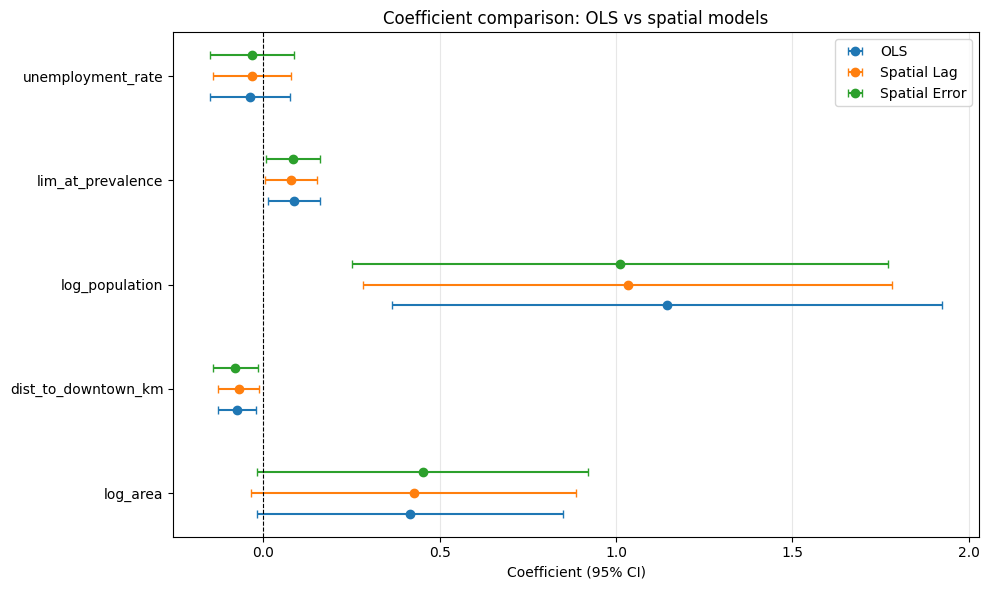

In [60]:
# Coefficient comparison plot — forest plot style
fig, ax = plt.subplots(figsize=(10, 6))

def extract_coefs(model, name, color, y_offset):
    betas = np.array(model.betas).flatten()
    std_err = np.array(model.std_err).flatten()
    n_x = len(X_cols)
    # spreg orders: [constant, X..., (rho or lambda for spatial models)]
    coefs = betas[1:1 + n_x]
    ses = std_err[1:1 + n_x]
    y_pos = np.arange(n_x) + y_offset
    ax.errorbar(coefs, y_pos, xerr=1.96 * ses, fmt="o", color=color,
                label=name, capsize=3, markersize=6)

extract_coefs(ols_model, "OLS", "#1f77b4", -0.2)
extract_coefs(lag_model, "Spatial Lag", "#ff7f0e", 0.0)
extract_coefs(err_model, "Spatial Error", "#2ca02c", 0.2)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_yticks(np.arange(len(X_cols)))
ax.set_yticklabels(X_cols)
ax.set_xlabel("Coefficient (95% CI)")
ax.set_title("Coefficient comparison: OLS vs spatial models")
ax.legend(loc="best")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


### 8.5.9 Mapping model residuals

Where does the model under-predict (positive residual: more incidents than expected given the features) versus over-predict (negative residual)? Persistent under-prediction in the downtown shelter zone would be a direct visual confirmation of the single-shelter concentration finding from Section 7 — the model can't fully explain it from neighborhood-level features because the driver is at sub-neighborhood scale.


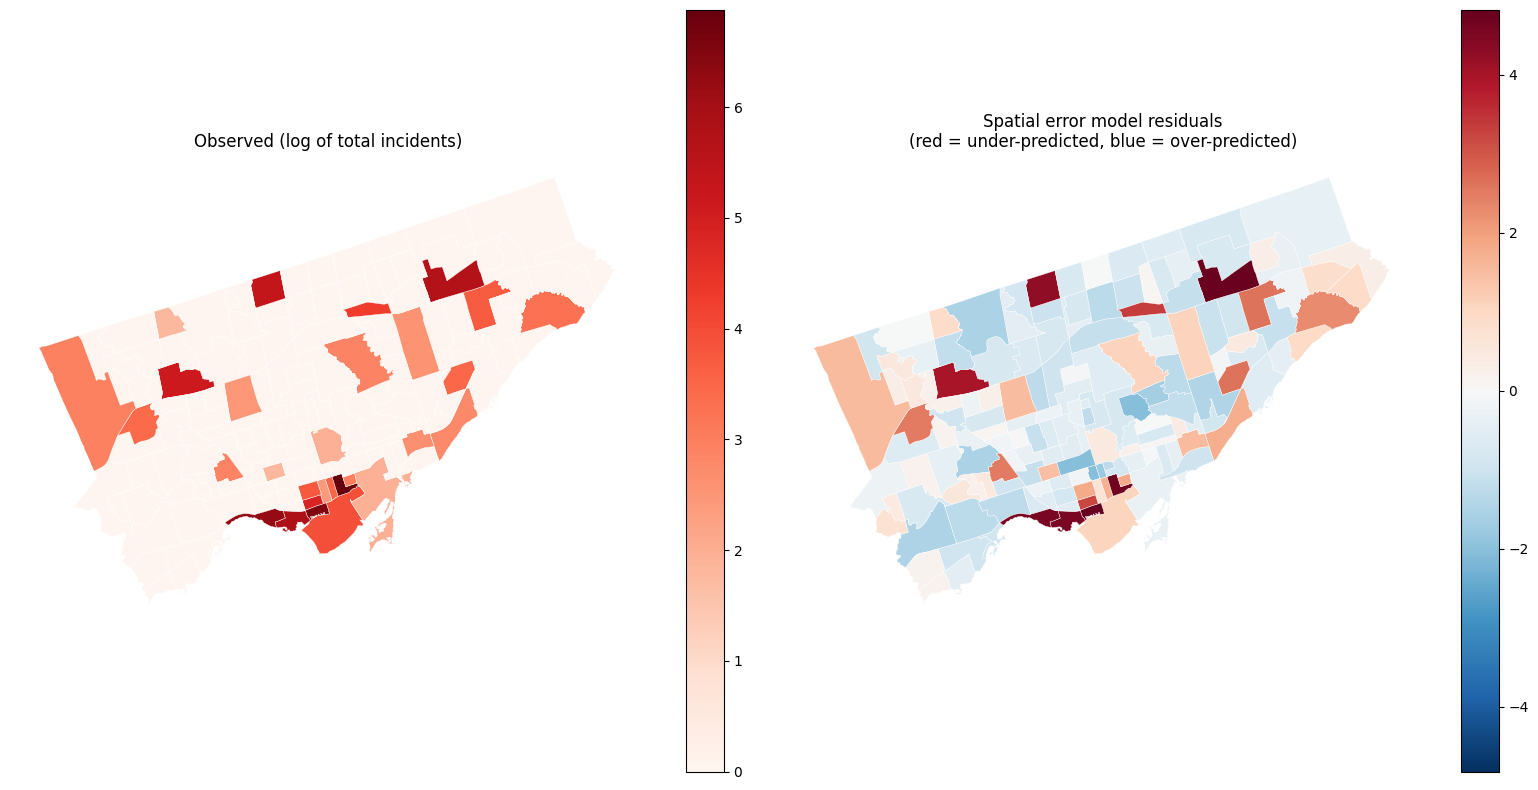

In [61]:
# Attach residuals back to the geodataframe
model_df["ols_resid"] = ols_model.u.flatten()
model_df["spatial_lag_resid"] = lag_model.u.flatten()
model_df["spatial_err_resid"] = err_model.u.flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Observed log-incidents
model_df.plot(column="log_incidents", cmap="Reds", legend=True,
              edgecolor="white", linewidth=0.3, ax=axes[0])
axes[0].set_title("Observed (log of total incidents)")
axes[0].axis("off")

# Spatial error model residuals (centered colormap)
vmax = np.abs(model_df["spatial_err_resid"]).max()
model_df.plot(column="spatial_err_resid", cmap="RdBu_r", legend=True,
              edgecolor="white", linewidth=0.3, ax=axes[1],
              vmin=-vmax, vmax=vmax)
axes[1].set_title("Spatial error model residuals\n(red = under-predicted, blue = over-predicted)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


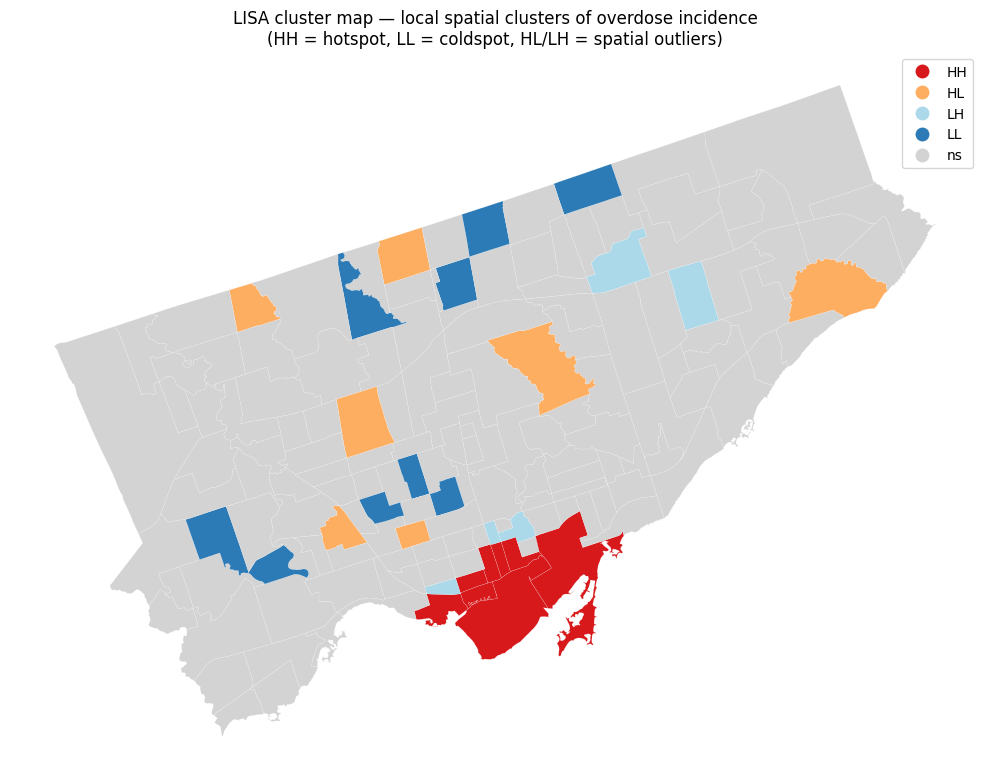

In [62]:
# Local Moran's I (LISA) on observed values — identifies clusters and outliers
lisa = Moran_Local(model_df["log_incidents"].values, w_queen, permutations=999)

fig, ax = plt.subplots(figsize=(10, 10))
lisa_cluster(lisa, model_df, p=0.05, ax=ax)
ax.set_title("LISA cluster map — local spatial clusters of overdose incidence\n"
             "(HH = hotspot, LL = coldspot, HL/LH = spatial outliers)")
ax.axis("off")
plt.tight_layout()
plt.show()


### 8.5.10 Findings and interpretation

#### 1. The spatial lag model resolves residual autocorrelation; the spatial error model does not

The cleanest diagnostic in this section is the residual Moran's I after each model:

| Model | Residual Moran's I | p-value |
|---|---|---|
| OLS (HC3) | +0.057 | 0.086 |
| **Spatial Lag** | **-0.024** | **0.381** |
| Spatial Error | +0.064 | 0.078 |

The spatial lag specification successfully absorbs the residual spatial structure (Moran's I collapses to near zero), while the spatial error model leaves it essentially untouched. This single diagnostic settles which spatial form is appropriate, regardless of how the AIC ranking happens to fall. Even though the spatial autoregressive parameter ρ is only marginally significant (ρ = 0.207, p = 0.075), the model that uses it is *behaving correctly* in a way the alternative isn't.

#### 2. Socioeconomic and exposure variables explain most of the geographic clustering

Moran's I on the OLS residuals before adding the spatial term is just 0.057 (p = 0.086) — below the conventional α = 0.05 threshold. Compare this to the strong unconditional spatial clustering visible in the descriptive maps from Section 7: once we control for population, neighborhood area, distance to downtown, low-income concentration (LIM-AT), and unemployment, most of that apparent clustering is absorbed by the predictors themselves.

The substantive interpretation: **neighborhoods that are geographically close tend to share the demographic and economic features that drive overdose incidence.** What looks like a "spatial process" in the raw data is largely a *socioeconomic process that happens to be spatially organized*. This shifts the burden of explanation away from geography per se and toward neighborhood characteristics — a more useful finding for policy and a more defensible one statistically.

#### 3. Substantive coefficient story (with HC3 robust standard errors)

After dropping median income for multicollinearity (condition number dropped from 127 to 109) and switching to HC3 heteroskedasticity-consistent standard errors:

| Predictor | OLS | Spatial Lag | Spatial Error |
|---|---|---|---|
| log_population | +1.14 \*\* | +1.03 \*\* | +1.01 \*\* |
| dist_to_downtown_km | -0.075 \*\* | -0.070 \* | -0.080 \* |
| **lim_at_prevalence** | **+0.086 \*** | **+0.079 \*** | **+0.083 \*** |
| log_area | +0.42 . | +0.43 . | +0.45 . |
| unemployment_rate | -0.04 | -0.03 | -0.03 |

*Signif.: \*\* p<0.01, \* p<0.05, . p<0.10*

Three substantive findings:

**LIM-AT prevalence is the central socioeconomic predictor.** Each 1-percentage-point increase in the share of households in low income (after-tax) is associated with roughly an 8% increase in expected incidents, holding population, area, downtown distance, and unemployment constant. This is the cleanest interview-quotable finding in the modeling section — it converts the descriptive observation "overdoses concentrate in poorer neighborhoods" into a coefficient with a defensible inferential story. It only emerges this clearly *after* the HC3 correction, because the heteroskedasticity was concentrated in exactly the high-LIM-AT downtown neighborhoods where the variance is largest.

**Distance to downtown captures a real geographic gradient.** Each kilometre from the downtown core reduces expected log-incidents by about 7-8%, and this coefficient is *robust* to including the spatial lag term — meaning it's a substantive feature of the data, not a statistical artifact picking up spatial autocorrelation through the back door. If it had been spurious, we would expect it to shrink toward zero in the spatial lag model. It doesn't.

**Unemployment rate carries no independent signal.** It enters as non-significant in all three specifications. This is almost certainly because LIM-AT already absorbs the relevant socioeconomic information; unemployment at neighborhood scale is volatile, lagged in Census data, and correlated with LIM-AT. A reasonable next iteration would drop it entirely.

#### 4. Where the model still fails — and why this reinforces the Section 7 finding

The residual choropleth (Section 8.5.9) shows the largest under-predictions concentrated in **Moss Park, Harbourfront-CityPlace, and South Parkdale** — exactly the neighborhoods where Section 7 identified that a single shelter or facility address accounts for the majority of incidents. The neighborhood-level model cannot capture this because the driver operates *below* the neighborhood scale.

This is the unusual case where a model's failure *strengthens* an earlier finding rather than undermining it. The descriptive analysis identified facility-level concentration; the modeling layer confirms that **no plausible set of neighborhood-level features can fully explain it.** Further progress would require point-level or building-level data — shelter bed counts, supervised consumption site proximity measured in metres rather than polygon membership, facility-specific operational characteristics.

#### 5. Limitations

- **Ecological fallacy.** Neighborhood-level associations do not translate to individual-level overdose risk. A neighborhood with high LIM-AT and high incident count does not mean low-income individuals within that neighborhood are at higher risk — that requires individual-level data.
- **Modifiable Areal Unit Problem (MAUP).** The 158-neighborhood polygons are an administrative construct; results may differ at finer (dissemination area, hex grid) or coarser scales. A robustness check at H3 resolution 8 is a natural appendix extension.
- **Cross-sectional pooling.** We collapsed 2018–2025 into a single count. A panel spatial model with year fixed effects would let us study how the spatial structure of the crisis *changed* over time, including any structural break around COVID that the Section 5 time series suggests.
- **Missing predictors.** Supervised consumption site locations, shelter bed capacities, policing patterns, and fentanyl supply indicators are all plausibly correlated with both overdose incidence and the included covariates. Their omission biases the estimates we do have.
- **Count outcome modeled as log-linear.** A negative binomial GLM with an offset for log-population would be more principled for count data with the overdispersion observed here. With 95 of 158 neighborhoods at zero incidents, a zero-inflated NB or hurdle model would be the most rigorous next iteration.
- **Marginal spatial parameter.** Although the spatial lag specification cleans up residual autocorrelation, ρ itself is only significant at p = 0.075. The improvement over OLS should be characterized as "diagnostically necessary but substantively modest" rather than "transformative."

#### Bottom line

Spatial regression on Toronto neighborhood overdose data shows that **most of the apparent geographic clustering is mediated through socioeconomic and exposure variables**, not by an unobserved "spatial process." LIM-AT prevalence emerges as the central socioeconomic predictor under heteroskedasticity-consistent inference, with each percentage-point increase in low-income concentration associated with roughly 8% more incidents. The spatial lag specification is diagnostically appropriate (it eliminates residual spatial autocorrelation) and is preferred to the spatial error alternative even though both have similar AIC values. The model's remaining failures concentrate in the downtown shelter corridor, confirming that the overdose burden in those neighborhoods is driven by sub-neighborhood facility-level dynamics that no neighborhood-level regression can capture — a finding that reinforces, rather than contradicts, the central result of Section 7.


## 9. Conclusion & Recommendations

### Summary

Suspected non-fatal opioid overdoses in Toronto followed a pronounced arc over 2018–2025: a period of escalation driven by fentanyl contamination and pandemic disruption, peaking sharply in 2021, and declining consistently thereafter. However, the aggregate decline should not obscure important spatial heterogeneity. A small number of addresses — particularly those co-located with emergency shelters and transitional housing — carry a grossly disproportionate burden.

### Recommendations

1. **Sustain and expand harm reduction at high-burden addresses.** Sites like 339 George St and 545 Lake Shore Blvd W warrant dedicated naloxone access, supervised consumption services, and outreach staffing regardless of year-to-year fluctuations in city-wide counts.

2. **Monitor the Scarborough corridor.** The rising trend at 2035 Kennedy Rd suggests that overdose burden is shifting eastward. Early investment in mobile outreach and naloxone distribution in this area is warranted before counts reach crisis levels.

3. **Investigate the 2025 uptick at 339 GEORGE ST.** The apparent data variant (capitalized form) and elevated 2025 count should be resolved through data reconciliation and field verification.

4. **Use quarterly data for seasonal analysis.** The `year_stage` (Q1–Q4) variable in the source dataset was not fully exploited in this analysis. Seasonal decomposition could identify whether overdoses spike in particular quarters, informing staffing and outreach calendar planning.

5. **Interpret 2025 figures cautiously.** The low 2025 count (~280) likely reflects partial-year reporting. Year-end projections should be compared to prior years once complete data are available.

6. **Prioritize the Billy Bishop airport-zone shelter for immediate intervention.** With a single shelter address responsible for over 77% of overdose incidents within the 10 km airport corridor, this location represents one of the highest-leverage intervention points in the entire dataset. Dedicated on-site harm reduction services — including supervised consumption, naloxone distribution, and outreach staffing — should be considered as a matter of urgency. Coordination between the shelter operator, Toronto Public Health, and local harm reduction networks is recommended.

### Limitations

- Suppressed `<5` counts introduce small-count imprecision; aggregate city-level totals are reliable, but address-level comparisons for low-count locations carry uncertainty.
- Geocoding accuracy depends on address standardization; minor variants (e.g., `339 George St` vs. `339 GEORGE ST`) may split what are effectively the same location.
- The dataset captures *suspected* non-fatal overdoses reported to or observed by specific services; under-reporting in areas with lower service density is likely.

---
*Analysis conducted using Python (pandas, matplotlib, seaborn, folium, geopandas). Data sourced from the City of Toronto Open Data Portal.*

## 10. Where This Data Can Be Found

All data used in this analysis are publicly available and freely accessible. No registration or login is required.

---

### 📂 Primary Dataset

**Suspected Opioid Overdose Incidents (SOOIS)**  
Maintained by: City of Toronto  
Portal: [Toronto Open Data Catalogue](https://open.toronto.ca/dataset/suspected-opioid-overdose-incidents/)  
Format: CSV (downloadable directly from the portal)  
Update frequency: Quarterly  
Coverage: 2018 – present, aggregated by address, year, and quarter

**How to download:**
1. Visit the link above
2. Click **Explore** → **Download**
3. Select the CSV format
4. The file used in this report was saved locally as `soois.csv`

---

### 🗺️ Geocoding

Address coordinates were resolved using the **Nominatim geocoder** (OpenStreetMap), accessed via the `geopy` Python library.  
Results were cached locally as `geocoded_addresses.csv` to avoid repeated API calls on re-runs.

---

### ✈️ Airport Reference Point

The Billy Bishop Toronto City Airport (YTZ) coordinates used for proximity analysis:  
**Latitude:** 43.6777 N  |  **Longitude:** 79.6248 W  
Source: [Billy Bishop Airport — Wikipedia](https://en.wikipedia.org/wiki/Billy_Bishop_Toronto_City_Airport)

---

### 🔧 Tools & Libraries

| Library | Purpose | Install |
|---|---|---|
| `pandas` | Data loading and aggregation | `pip install pandas` |
| `numpy` | Numerical operations | `pip install numpy` |
| `matplotlib` / `seaborn` | Static charts and heatmaps | `pip install matplotlib seaborn` |
| `folium` | Interactive maps | `pip install folium` |
| `geopandas` | Spatial data handling | `pip install geopandas` |
| `geopy` | Address geocoding | `pip install geopy` |
| `statsmodels` | Regression analysis | `pip install statsmodels` |
| `contextily` | Basemap tiles | `pip install contextily` |

---

### 📬 Contact & Reproducibility

This analysis was prepared by **Ayokunmi Lawal**.  
All code is contained within this Jupyter Notebook and can be re-run in sequence against the source CSV.  
To reproduce results from scratch, replace `geocoded_addresses.csv` with a fresh geocoding run (note: Nominatim rate-limits to 1 request/second; allow ~15–20 minutes for full geocoding of all unique addresses).
